# Creating the training set
### From 2040x2040 images of full detectors **to** 512x512 patches

- Read detector images
- Apply random mask
- Create 512x512 patches
- Save into a final **training set**: one for each configuration (4)

In [1]:
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from gelsa import visu
from tqdm.notebook import tqdm
import random

## Random "bad-pixels" mask

We want to apply a random bad-pixel mask to the training images such that the Neural Network learns how to inpaint them. We can get masks from the 2 real-data pointings we have downloaded and then define a function that applies a random flip.

In [2]:
from gelsa.sgs import datastore
import gelsa

In [3]:
real_ids = [30399, 30477] #, 30444]
grism_config = ['4_RGS180', '0_RGS180']#, 'minus4_000']

In [4]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )
# Load the data related to the pointing_id
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=real_ids)

G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)
# Define the frame associated to the pointing
frame_1 = G.load_spec_frame(**file_list[0])
frame_2 = G.load_spec_frame(**file_list[1])
# frame_3 = G.load_spec_frame(**file_list[2])

got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30477, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30477'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-

In [5]:
masks = []
for det in tqdm(range(16)):
    im, mask, var = frame_1.get_detector(det)
    masks.append(mask)
    im, mask, var = frame_2.get_detector(det)
    masks.append(mask)

masks = np.array(masks)
# masks[masks != np.max(masks)] = 0
masks[masks > 0] = 1

  0%|          | 0/16 [00:00<?, ?it/s]

In [6]:
np.unique(masks)

array([0, 1], dtype=uint32)

In [7]:
def pick_random_masks(masks, size=100, flip=False, random_seed = 10):
    #Setting random seeds
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    flip_masks = masks.copy()
    new_list = np.zeros((size, masks.shape[1], masks.shape[2]))
    for i in tqdm(range(len(new_list))):
        flip_h = np.random.rand() < 0.5 
        flip_v = np.random.rand() < 0.5
        # Pick a random mask
        rand_ind = random.randint(0, len(masks)-1)
        selected_mask = masks[rand_ind]
        # Apply a random flip
        if flip:
            if flip_h:
                selected_mask = np.fliplr(selected_mask)  # horizontal flip
            if flip_v:
                selected_mask = np.flipud(selected_mask)  # vertical flip
        # Add it to the list
        new_list[i] = selected_mask
    return new_list

In [8]:
mask_list = pick_random_masks(masks, size=96, flip=True)
mask_list_noflip = pick_random_masks(masks, size=96, flip=False)

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

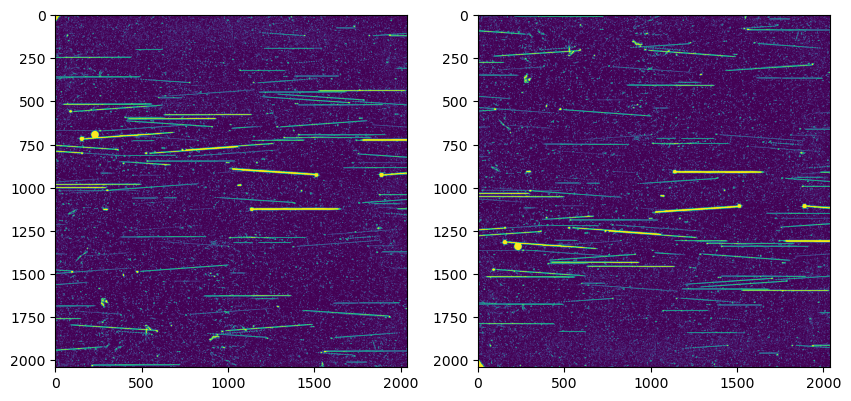

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

plt.subplot(121)
plt.imshow(visu.normalize_image(mask_list_noflip[56], levels=(5, 99)))

plt.subplot(122)
plt.imshow(visu.normalize_image(mask_list[56], levels=(5, 99)))

---

### Set the value of the `lines` variable:
- #### `True` if I want to save the training sets: In this case a bad-pixel **mask** will be applied
- #### `False` if I want to save the labels. No mask in this case

In [32]:
lines = True

In [33]:
suffix = "_EL" if lines else ""

In [34]:
print(suffix)

_EL


In [35]:
# RGS000, 0 tilt
hdu_30454 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30454{suffix}.fits", memmap=True)
hdu_30378 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30378{suffix}.fits", memmap=True)
hdu_30370 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30370{suffix}.fits", memmap=True)
hdu_30358 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30358{suffix}.fits", memmap=True)
hdu_30362 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30362{suffix}.fits", memmap=True)
hdu_30458 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_0/simulated_images_30458{suffix}.fits", memmap=True)

# RGS000, -4 tilt
hdu_30512 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30512{suffix}.fits", memmap=True)
hdu_30364 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30364{suffix}.fits", memmap=True)
hdu_30372 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30372{suffix}.fits", memmap=True)
hdu_30488 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30488{suffix}.fits", memmap=True)
hdu_30456 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30456{suffix}.fits", memmap=True)
hdu_30432 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS000_minus4/simulated_images_30432{suffix}.fits", memmap=True)

# RGS180, 0 tilt
hdu_30381 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30381{suffix}.fits", memmap=True)
hdu_30473 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30473{suffix}.fits", memmap=True)
hdu_30365 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30365{suffix}.fits", memmap=True)
hdu_30369 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30369{suffix}.fits", memmap=True)
hdu_30449 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30449{suffix}.fits", memmap=True)
hdu_30509 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_0/simulated_images_30509{suffix}.fits", memmap=True)

# RGS180, +4 tilt
hdu_30375 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30375{suffix}.fits", memmap=True)
hdu_30487 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30487{suffix}.fits", memmap=True)
hdu_30379 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30379{suffix}.fits", memmap=True)
hdu_30507 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30507{suffix}.fits", memmap=True)
hdu_30371 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30371{suffix}.fits", memmap=True)
hdu_30399 = fits.open(f"/scratch/astro/nicolo.fiaba/simulated_images/RGS180_4/simulated_images_30399{suffix}.fits", memmap=True)

In [36]:
# RGS000, 0 tilt
imgs_30454 = np.array([hdu.data for hdu in hdu_30454[1:]])
imgs_30378 = np.array([hdu.data for hdu in hdu_30378[1:]])
imgs_30370 = np.array([hdu.data for hdu in hdu_30370[1:]])
imgs_30358 = np.array([hdu.data for hdu in hdu_30358[1:]])
imgs_30362 = np.array([hdu.data for hdu in hdu_30362[1:]])
imgs_30458 = np.array([hdu.data for hdu in hdu_30458[1:]])

# RGS000, -4 tilt
imgs_30512 = np.array([hdu.data for hdu in hdu_30512[1:]])
imgs_30364 = np.array([hdu.data for hdu in hdu_30364[1:]])
imgs_30372 = np.array([hdu.data for hdu in hdu_30372[1:]])
imgs_30488 = np.array([hdu.data for hdu in hdu_30488[1:]])
imgs_30456 = np.array([hdu.data for hdu in hdu_30456[1:]])
imgs_30432 = np.array([hdu.data for hdu in hdu_30432[1:]])

# RGS180, 0 tilt
imgs_30381 = np.array([hdu.data for hdu in hdu_30381[1:]])
imgs_30473 = np.array([hdu.data for hdu in hdu_30473[1:]])
imgs_30365 = np.array([hdu.data for hdu in hdu_30365[1:]])
imgs_30369 = np.array([hdu.data for hdu in hdu_30369[1:]])
imgs_30449 = np.array([hdu.data for hdu in hdu_30449[1:]])
imgs_30509 = np.array([hdu.data for hdu in hdu_30509[1:]])

# RGS180, +4 tilt
imgs_30375 = np.array([hdu.data for hdu in hdu_30375[1:]])
imgs_30487 = np.array([hdu.data for hdu in hdu_30487[1:]])
imgs_30379 = np.array([hdu.data for hdu in hdu_30379[1:]])
imgs_30507 = np.array([hdu.data for hdu in hdu_30507[1:]])
imgs_30371 = np.array([hdu.data for hdu in hdu_30371[1:]])
imgs_30399 = np.array([hdu.data for hdu in hdu_30399[1:]])

In [37]:
# RGS000, 0 tilt
imgs_RGS000_0 = np.array([
    imgs_30454,
    imgs_30378,
    imgs_30370,
    imgs_30358,
    imgs_30362,
    imgs_30458
])

# RGS000, -4 tilt
imgs_RGS000_minus4 = np.array([
    imgs_30512,
    imgs_30364,
    imgs_30372,
    imgs_30488,
    imgs_30456,
    imgs_30432
])

# RGS180, 0 tilt
imgs_RGS180_0 = np.array([
    imgs_30381,
    imgs_30473,
    imgs_30365,
    imgs_30369,
    imgs_30449,
    imgs_30509
])

# RGS180, +4 tilt
imgs_RGS180_4 = np.array([
    imgs_30375,
    imgs_30487,
    imgs_30379,
    imgs_30507,
    imgs_30371,
    imgs_30399
])

In [38]:
images = np.concatenate([
    imgs_RGS000_0,
    imgs_RGS000_minus4,
    imgs_RGS180_0,
    imgs_RGS180_4
], axis=0)

In [39]:
imgs_RGS000_0 = imgs_RGS000_0.reshape(-1, 2040, 2040)
imgs_RGS000_minus4 = imgs_RGS000_minus4.reshape(-1, 2040, 2040)
imgs_RGS180_0 = imgs_RGS180_0.reshape(-1, 2040, 2040)
imgs_RGS180_4 = imgs_RGS180_4.reshape(-1, 2040, 2040)

In [40]:
tilt_0_000 = ["0" for i in range(6)]
tilt_minus4_000 = ["-4" for i in range(6)]
tilt_0_180 = ["0" for i in range(6)]
tilt_4_180 = ["+4" for i in range(6)]

tilts = tilt_0_000 + tilt_minus4_000 + tilt_0_180 + tilt_4_180

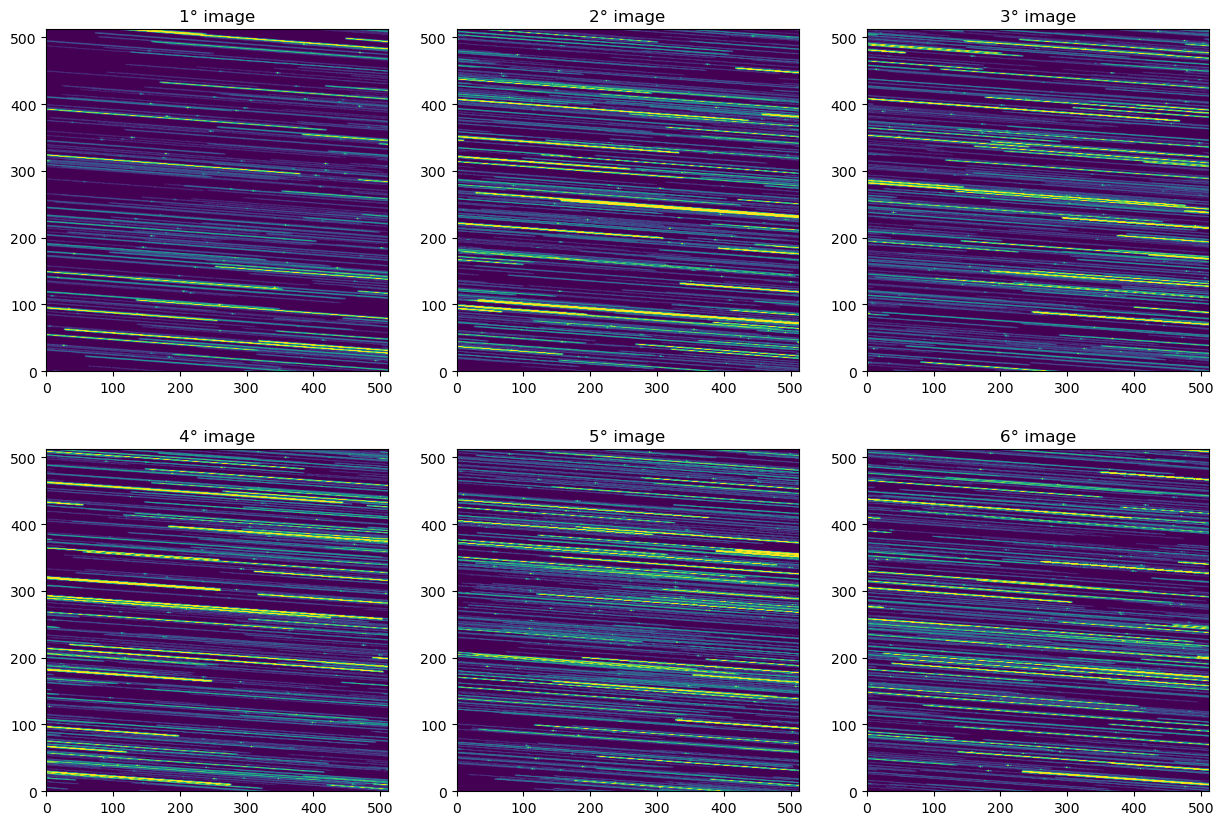

In [43]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(visu.normalize_image(imgs_RGS000_minus4[i], levels=(5, 95)), origin='lower');
    ax.set_title('{}° image'.format(i+1))
    ax.set_xlim(0, 512)
    ax.set_ylim(0, 512)

# plt.savefig("sim_with_emission_lines.png")

#### Apply random mask to detectors **IF** `lines=True`, to create two datasets:
- Training set: masked
- Labels: Not masked

In [44]:
def apply_mask(images, masks, random_seed, flip, size):
    mask_list = pick_random_masks(masks, size=size, flip=flip, random_seed=random_seed)
    images_masked = images.copy()
    images_masked[mask_list == 1] = np.nan
    return images_masked

#### If `lines = False` the following cell is not executed. No lines $\rightarrow$ No mask

In [45]:
if lines:
    imgs_RGS000_0_masked = apply_mask(imgs_RGS000_0, masks, random_seed=12, flip=True, size=96)
    imgs_RGS000_minus4_masked = apply_mask(imgs_RGS000_minus4, masks, random_seed=42, flip=True, size=96)
    imgs_RGS180_0_masked = apply_mask(imgs_RGS180_0, masks, random_seed=22, flip=True, size=96)
    imgs_RGS180_4_masked = apply_mask(imgs_RGS180_4, masks, random_seed=32, flip=True, size=96)

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

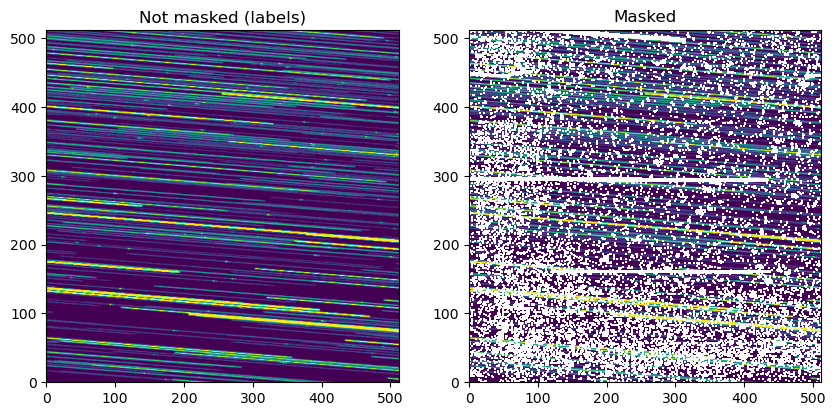

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
lim = 512
plt.subplot(121)
plt.imshow(visu.normalize_image(imgs_RGS000_minus4[31], levels=(5, 95)))
plt.title("Not masked (labels)")
plt.xlim(0, lim)
plt.ylim(0, lim)

if lines:
    plt.subplot(122)
    plt.imshow(visu.normalize_image(imgs_RGS000_minus4_masked[31], levels=(5, 95)))
    plt.title("Masked")
    plt.xlim(0, lim)
    plt.ylim(0, lim)

### Slicing into patches $(512 \times 512)$

In [49]:
# adapted from https://github.com/obss/sahi/blob/e798c80d6e09079ae07a672c89732dd602fe9001/sahi/slicing.py#L30, MIT License
def calculate_slice_bboxes(
    image_height: int = 2040,
    image_width: int = 2040,
    slice_height: int = 512,
    slice_width: int = 512,
    overlap_height_ratio: float = 0.5,
    overlap_width_ratio: float = 0.5,
) -> list[list[int]]:
    """
    Given the height and width of an image, calculates how to divide the image into
    overlapping slices according to the height and width provided. These slices are returned
    as bounding boxes in xyxy format.
    :param image_height: Height of the original image.
    :param image_width: Width of the original image.
    :param slice_height: Height of each slice
    :param slice_width: Width of each slice
    :param overlap_height_ratio: Fractional overlap in height of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :param overlap_width_ratio: Fractional overlap in width of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :return: a list of bounding boxes in xyxy format
    """

    slice_bboxes = []
    y_max = y_min = 0
    y_overlap = int(overlap_height_ratio * slice_height)
    x_overlap = int(overlap_width_ratio * slice_width)
    while y_max < image_height:
        x_min = x_max = 0
        y_max = y_min + slice_height
        while x_max < image_width:
            x_max = x_min + slice_width
            if y_max > image_height or x_max > image_width:
                xmax = min(image_width, x_max)
                ymax = min(image_height, y_max)
                xmin = max(0, xmax - slice_width)
                ymin = max(0, ymax - slice_height)
                slice_bboxes.append([xmin, ymin, xmax, ymax])
            else:
                slice_bboxes.append([x_min, y_min, x_max, y_max])
            x_min = x_max - x_overlap
        y_min = y_max - y_overlap
    return slice_bboxes

In [50]:
"""
Each row in slices is [xmin, ymin, xmax, ymax] of a different patch
"""
slices = calculate_slice_bboxes()
slices = np.array(slices)

In [51]:
widths = [slices[i, 2] - slices[i, 0] for i in range(np.shape(slices)[0])]
heights = [slices[i, 3] - slices[i, 1] for i in range(np.shape(slices)[0])]

# Check that all patches are 512x512
def all_equal3(lst):
    return lst[:-1] == lst[1:]
print(all_equal3(widths), all_equal3(heights))

True True


In [52]:
# The first function creates an array of rectangular images (height, width) starting from a full detector (2040x2040)
from tqdm.notebook import tqdm

def create_patches(image, slices):
    patches = []
    for ind in range(len(slices)): # Loop over the patches (rows of slices)
        xmin, ymin, xmax, ymax = slices[ind]
        cropped = image[ymin:ymax, xmin:xmax]
        patches.append(cropped)
    patches = np.array(patches)
    return patches

# The second function applies the previous one on a full frame of 16 detectors and merges the results
def patch_frame(images, slices):
    patches_tot = []
    for i in tqdm(range(16)):
        batch = create_patches(images[i], slices)
        patches_tot.append(batch)
    patches_tot = np.stack(patches_tot, axis=0)
    patches_tot = np.reshape(patches_tot, (-1, 512, 512))
    return patches_tot

def create_patches_singlearray(images, slices):
    patches = []
    for im in tqdm(images):
        for ind in range(len(slices)): # Loop over the patches (rows of slices)
            xmin, ymin, xmax, ymax = slices[ind]
            cropped = im[ymin:ymax, xmin:xmax]
            patches.append(cropped)
    patches = np.array(patches)
    return patches

In [53]:
# Le patches non mascherate le facciamo comunque, sia che io abbia EL che non
patches_RGS000_0 = create_patches_singlearray(imgs_RGS000_0, slices)
patches_RGS000_minus4 = create_patches_singlearray(imgs_RGS000_minus4, slices)
patches_RGS180_0 = create_patches_singlearray(imgs_RGS180_0, slices)
patches_RGS180_4 = create_patches_singlearray(imgs_RGS180_4, slices)

if lines:
    patches_RGS000_0_masked = create_patches_singlearray(imgs_RGS000_0_masked, slices)
    patches_RGS000_minus4_masked = create_patches_singlearray(imgs_RGS000_minus4_masked, slices)
    patches_RGS180_0_masked = create_patches_singlearray(imgs_RGS180_0_masked, slices)
    patches_RGS180_4_masked = create_patches_singlearray(imgs_RGS180_4_masked, slices)

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

  0%|          | 0/96 [00:00<?, ?it/s]

In [56]:
patches_RGS180_0.shape

(4704, 512, 512)

#### Now we save the 4 training sets and the 4 label sets into files

In [57]:
import os
if not os.path.exists('/scratch/astro/nicolo.fiaba/training_sets_EL/'):
    os.makedirs('/scratch/astro/nicolo.fiaba/training_sets_EL/')

In [58]:
if lines:
    patches_tot = [patches_RGS000_0_masked, patches_RGS000_minus4_masked, patches_RGS180_0_masked, patches_RGS180_4_masked]
else:
    patches_tot = [patches_RGS000_0, patches_RGS000_minus4, patches_RGS180_0, patches_RGS180_4]
    
suffixes = ['RGS000_0', 'RGS000_minus4', 'RGS180_0', 'RGS180_4']

In [59]:
# select the set to be saved
for training_set, suffix in zip(patches_tot, suffixes):
    if lines:
        output_path = "/scratch/astro/nicolo.fiaba/training_sets_EL/train_"+suffix+".fits"
    else:    
        output_path = "/scratch/astro/nicolo.fiaba/training_sets_EL/labels_"+suffix+".fits"
    
    # Create the Primary HDU (main header)
    phdu = fits.PrimaryHDU()
    phdu.header["N_IMAGES"] = training_set.shape[0]
    
    # Create an HDUList starting with the primary HDU
    hdul = fits.HDUList([phdu])
    
    # Append each image sequentially
    for i in tqdm(range(training_set.shape[0])):
        img = training_set[i].astype(np.float32)
        hdu = fits.ImageHDU(img, name=f"IM{i}")
        hdul.append(hdu)
    
    # Write all HDUs to disk
    hdul.writeto(output_path, overwrite=True)
    
    print("File saved:", output_path)
    

  0%|          | 0/4704 [00:00<?, ?it/s]

File saved: /scratch/astro/nicolo.fiaba/training_sets_EL/train_RGS000_0.fits


  0%|          | 0/4704 [00:00<?, ?it/s]

File saved: /scratch/astro/nicolo.fiaba/training_sets_EL/train_RGS000_minus4.fits


  0%|          | 0/4704 [00:00<?, ?it/s]

File saved: /scratch/astro/nicolo.fiaba/training_sets_EL/train_RGS180_0.fits


  0%|          | 0/4704 [00:00<?, ?it/s]

File saved: /scratch/astro/nicolo.fiaba/training_sets_EL/train_RGS180_4.fits


#### Now time for training a Neural Network on this datasets. Go to "*att_UNet.ipynb*" notebook